<h1 align="center">EN3160 Assignment 1</h1>
<h2 align="center">Intensity Transformations and Neighborhood Filtering</h2>

**Name:** Anthony C.S.B.  
**Index Number:** 230045X

<h2 align="left">Question 1</h2>

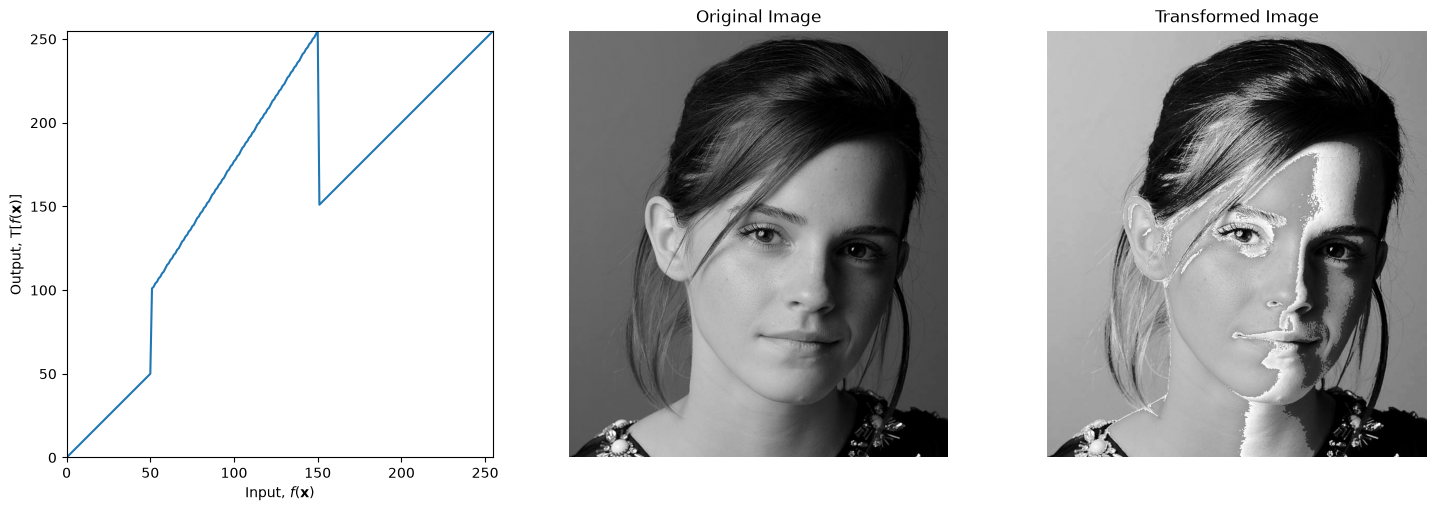

In [150]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def  intensity_transform(im, breakpoints):

    #First window is handled differently from the rest
    transform  = np.linspace(breakpoints[0,1],
                             breakpoints[1,1],
                             breakpoints[1,0]
                             -breakpoints[0,0]+1).astype('uint8')
        
    for i in range(2,len(breakpoints)):
        if (breakpoints[i-1,1]<255):
            window = np.linspace(breakpoints[i-1,1]+1,
                                 breakpoints[i,1],
                                 breakpoints[i,0]
                                 -breakpoints[i-1,0]).astype('uint8')
            transform = np.concatenate((transform,
                                         window), axis=0).astype('uint8')   
        else:
            window = np.linspace(breakpoints[i-1,1],
                                 breakpoints[i,1],
                                 breakpoints[i,0]
                                 -breakpoints[i-1,0]).astype('uint8')
            transform = np.concatenate((transform,
                                         window), axis=0).astype('uint8')   
      
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].plot(transform)
    ax[0].set_xlabel(r'Input, $f(\mathbf{x})$')
    ax[0].set_ylabel(r'Output, $\mathrm{T}[f(\mathbf{x})]$')
    ax[0].set_xlim(0,255)
    ax[0].set_ylim(0,255)
    ax[0].set_aspect('equal') 

    img_original = cv.imread(im, cv.IMREAD_GRAYSCALE)
    assert img_original is not None

    image_transformed = cv.LUT(img_original, transform)
    
    ax[1].imshow(img_original, cmap='gray')
    ax[1].set_title('Original Image')
    ax[1].axis('off')

    ax[2].imshow(image_transformed, cmap='gray')
    ax[2].set_title('Transformed Image')
    ax[2].axis('off')

    plt.tight_layout()
    plt.show(block=False)

intensity_transform("emma.jpg", np.array([(0,0),(50,50),
                                          (50,100),(150,255),
                                          (150,150),(255,255)]))


Given breakpoints stretched the mid-range intensities (50–150) into a wider output range (50–255). This increases contrast in that region. But the mapping drops suddenly at the breakpoint (150,255)→(150,150). This creates a discontinuity in the transform. The output image shows a visible false edge where input intensity crosses 150. This is seen as a sharp light-to-dark boundary on the face. This shows breakpoints should be chosen carefully to avoid unwanted artifacts, not just to boost contrast.

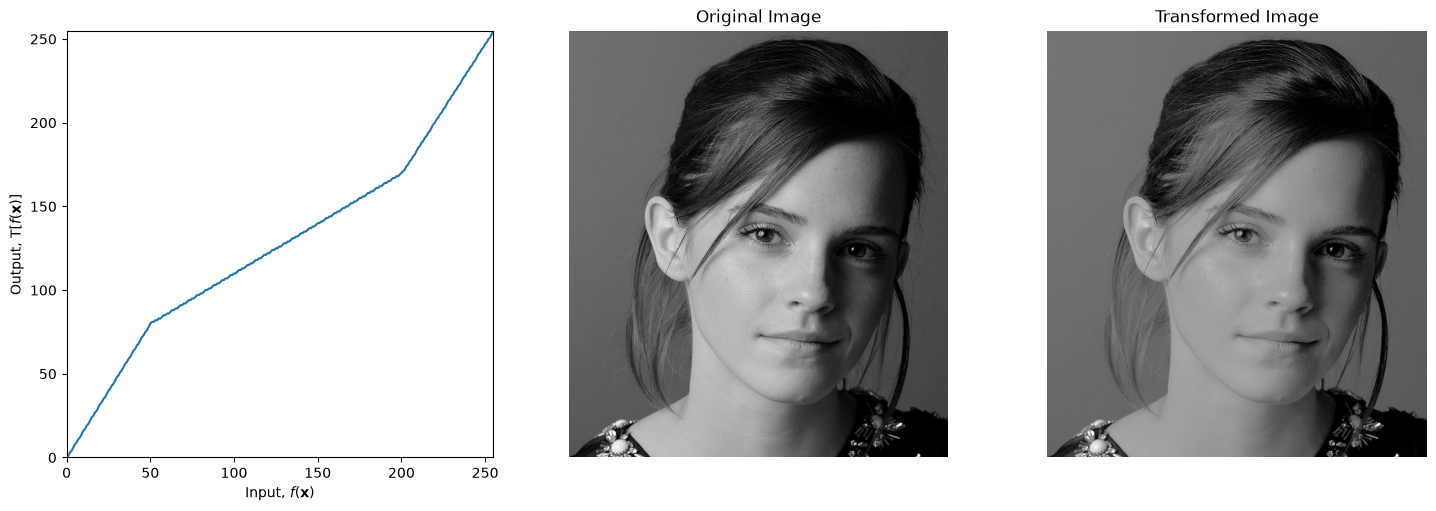

In [151]:
intensity_transform("emma.jpg", np.array([(0,0),(50,80),
                                          (200,170),(255,255)]))

In this implementation, both 0-50(dark) and 200-255(light) input pixels are stretched and the middle range(50-200) has compressed to limit its variations. Since there are no sudden jumps or falls in the intensity transformation, no visual artifacts can be seen in the output image.

<h2 align="left">Question 2</h2>

After searching how gray and white matter appear in a proton density image, I learnt the following and intensity windowing was applied accordingly.
- Gray Matter: Appears lighter or brighter gray because it has a higher proton (water) density and higher signal intensity.
- White Matter: Appears darker gray because it contains more myelin and less free water, resulting in a lower signal.
- Cerebrospinal Fluid (CSF): Appears very bright (hyperintense) due to its high water content - A very bright coloured, butterfly shaped patch which appears right in the middle of the given image. 

To determine the correct intensity ranges of gray and white matter to apply appropriate intensity windowing, I plotted the histogram of the given image first and then I compared it with a reference image of normal proton density image with named regions to clarify the intensity ranges.

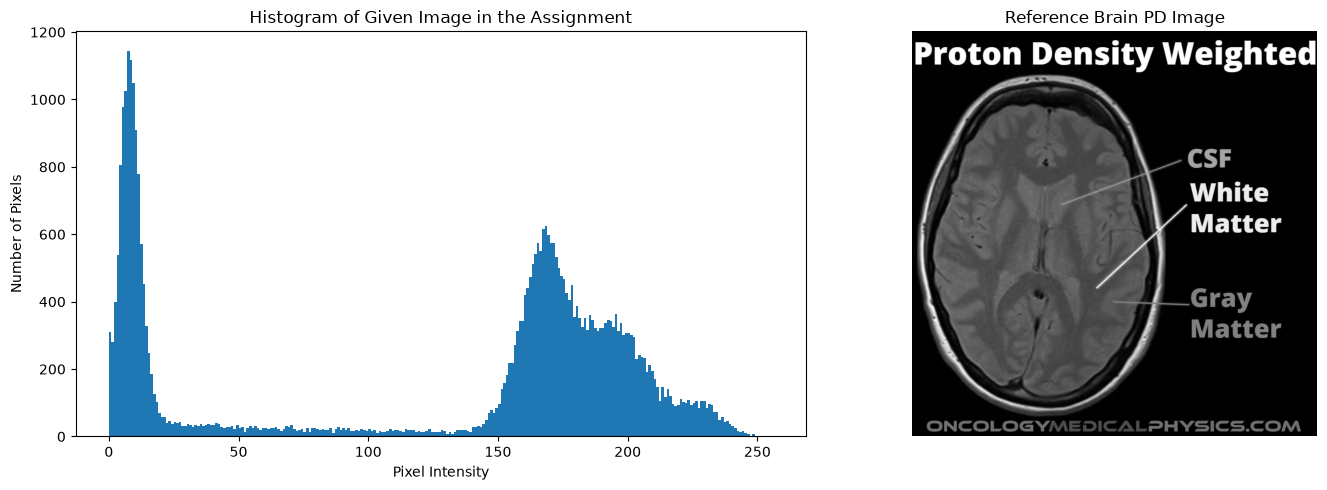

In [152]:
img1 = cv.imread("brain_PD_slice.jpg", cv.IMREAD_GRAYSCALE)
img2 = cv.imread("Proton-Density-Weighted.jpg", cv.IMREAD_GRAYSCALE)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].hist(img1.ravel(), bins=256, range=[0, 256])
ax[0].set_xlabel("Pixel Intensity")
ax[0].set_ylabel("Number of Pixels")
ax[0].set_title("Histogram of Given Image in the Assignment")

ax[1].imshow(img2, cmap='gray')
ax[1].set_title("Reference Brain PD Image")
ax[1].axis('off')

plt.tight_layout()
plt.show(block=False)

According to above histogram and reference image:
- White Matter - Intensity range of 145-180
- Gray Matter - Intensity range of 180-215

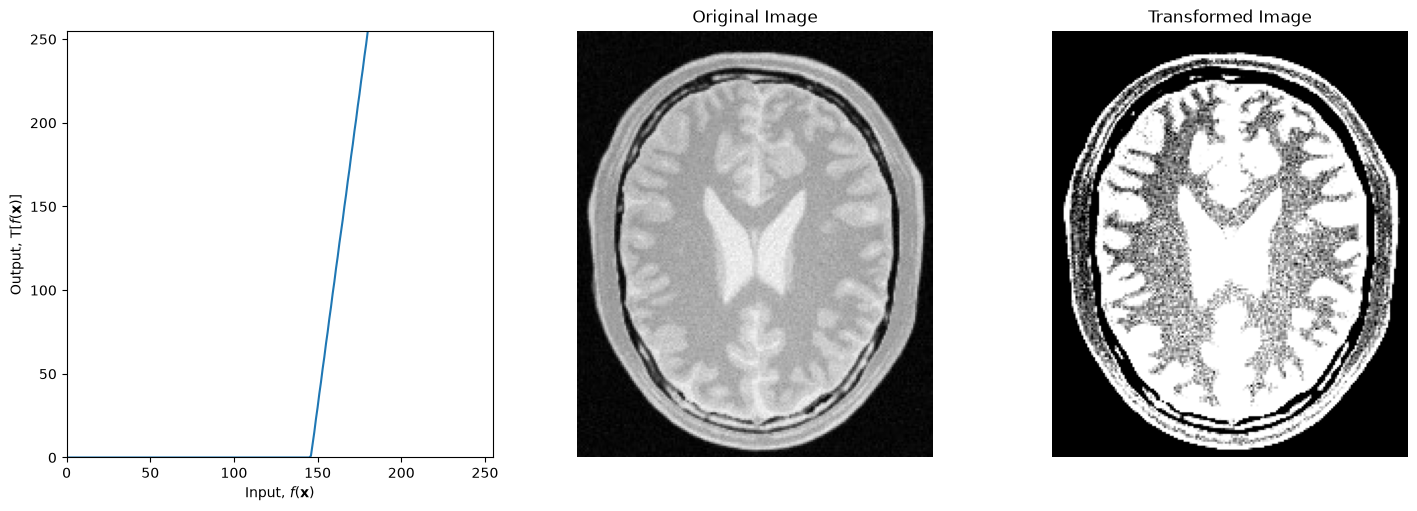

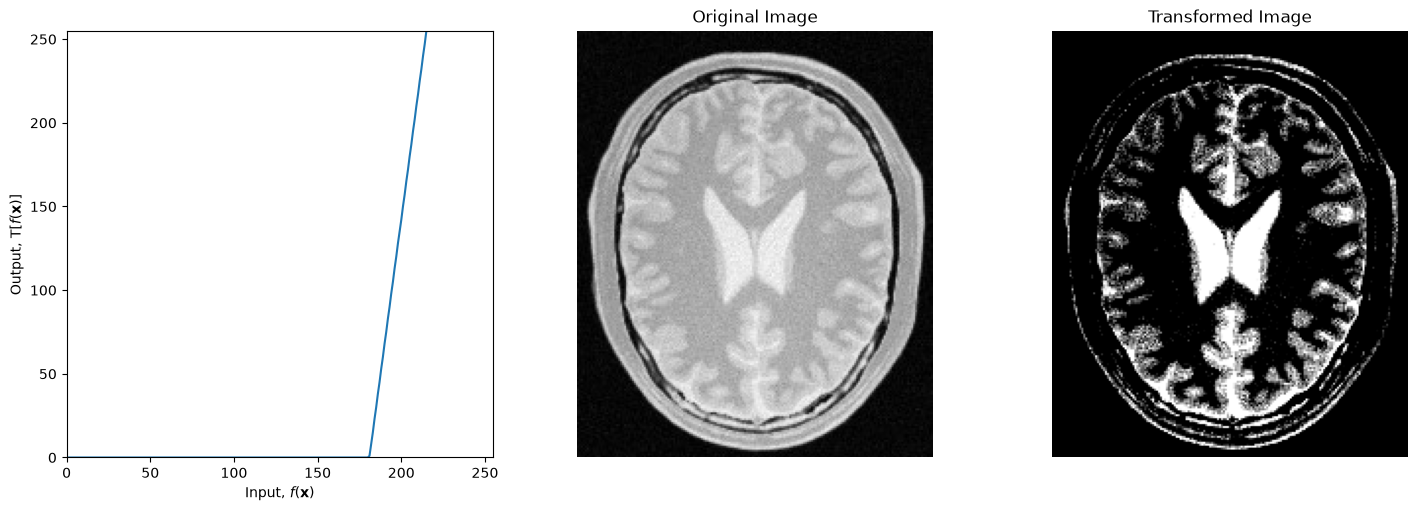

In [153]:
intensity_transform("brain_PD_slice.jpg",
                     np.array([(0,0), (145,0), 
                               (180,255), (255,255)])) #White Matter
intensity_transform("brain_PD_slice.jpg",
                     np.array([(0,0), (180,0), 
                               (215,255), (255,255)])) #Gray Matter 

<h2 align="left">Question 3</h2>

In this question, L, a and b planes are lightness, Green-Red Axis and Blue-Yellow Axis respectively. Only L plane is used for gamma correction to change only the brightness and keep colours untouched. For the gamma value, **0.5** is used because the given image has more dark pixels and the variation of dark pixels are not very sensitive to bare eye.

- $\gamma$ = 0.5

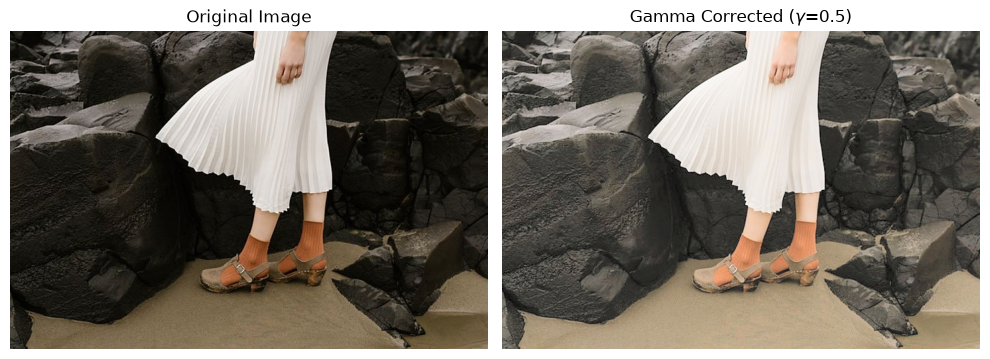

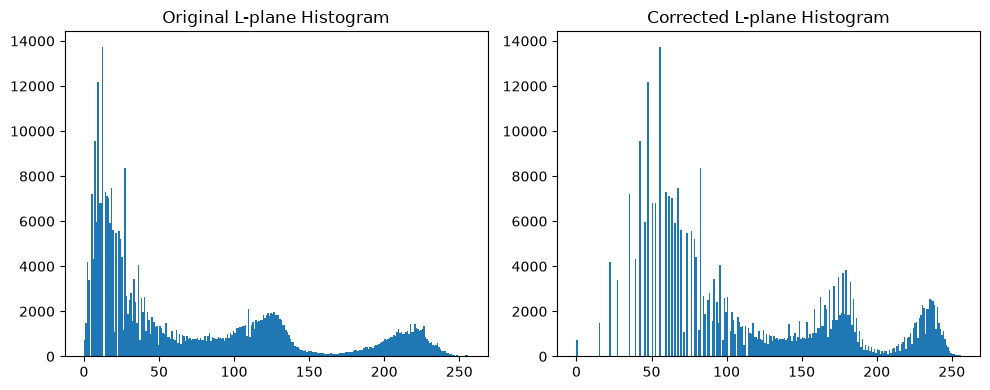

In [154]:
img_bgr = cv.imread('lady.jpg') 
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
img_lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2LAB)

L, a, b = cv.split(img_lab)
gamma = 0.5
table = np.array([((i / 255.0) ** gamma) * 255 
                  for i in np.arange(0, 256)]).astype("uint8")
L_corrected = cv.LUT(L, table)

img_lab_corrected = cv.merge((L_corrected, a, b))
img_corrected_rgb = cv.cvtColor(img_lab_corrected, cv.COLOR_LAB2RGB)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_corrected_rgb)
plt.title(rf'Gamma Corrected ($\gamma$={gamma})')
plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(L.ravel(), 256, range=[0, 256])
plt.title('Original L-plane Histogram')

plt.subplot(1, 2, 2)
plt.hist(L_corrected.ravel(), 256, range=[0, 256])
plt.title('Corrected L-plane Histogram')
plt.tight_layout()
plt.show()

<h2 align="left">Question 4</h2>

The vibrance function adds a Gaussian bump centered at saturation value 128. This boosts mid-saturation pixels the most. Pixels near 0 or 255 saturation are slightly changed. This avoids clipping already saturated colors and avoids increasing saturation of near-gray areas. With **a = 0.6**, the enhanced image shows brighter colors, especially in the clothing and faces. Another important observation is that the resulting intensity transformation curve is continously differentiable (No sharp corners).

- **a = 0.6**

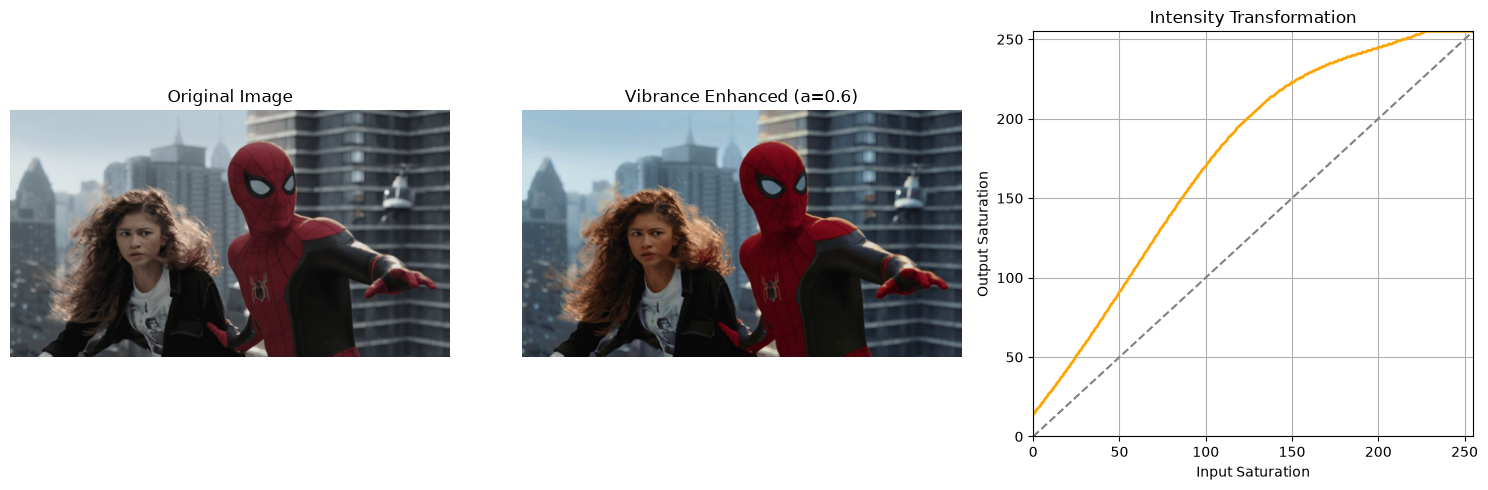

In [155]:
img_bgr = cv.imread('spider_man.jpg') 
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)

h, s, v = cv.split(img_hsv)
a = 0.6    
sigma = 70
x = np.arange(256) 

curve = x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2))
transform_curve = np.clip(curve, 0, 255).astype(np.uint8)

s_enhanced = cv.LUT(s, transform_curve)
img_hsv_enhanced = cv.merge((h, s_enhanced, v))
img_enhanced_rgb = cv.cvtColor(img_hsv_enhanced, cv.COLOR_HSV2RGB)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_enhanced_rgb)
plt.title(f'Vibrance Enhanced (a={a})')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.plot(x, transform_curve, color='orange', linewidth=2)
plt.plot(x, x, linestyle='--', color='gray') # Reference line y=x
plt.title('Intensity Transformation')
plt.xlabel('Input Saturation')
plt.ylabel('Output Saturation')
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)

plt.tight_layout()
plt.show()

<h2 align="left">Question 5</h2>

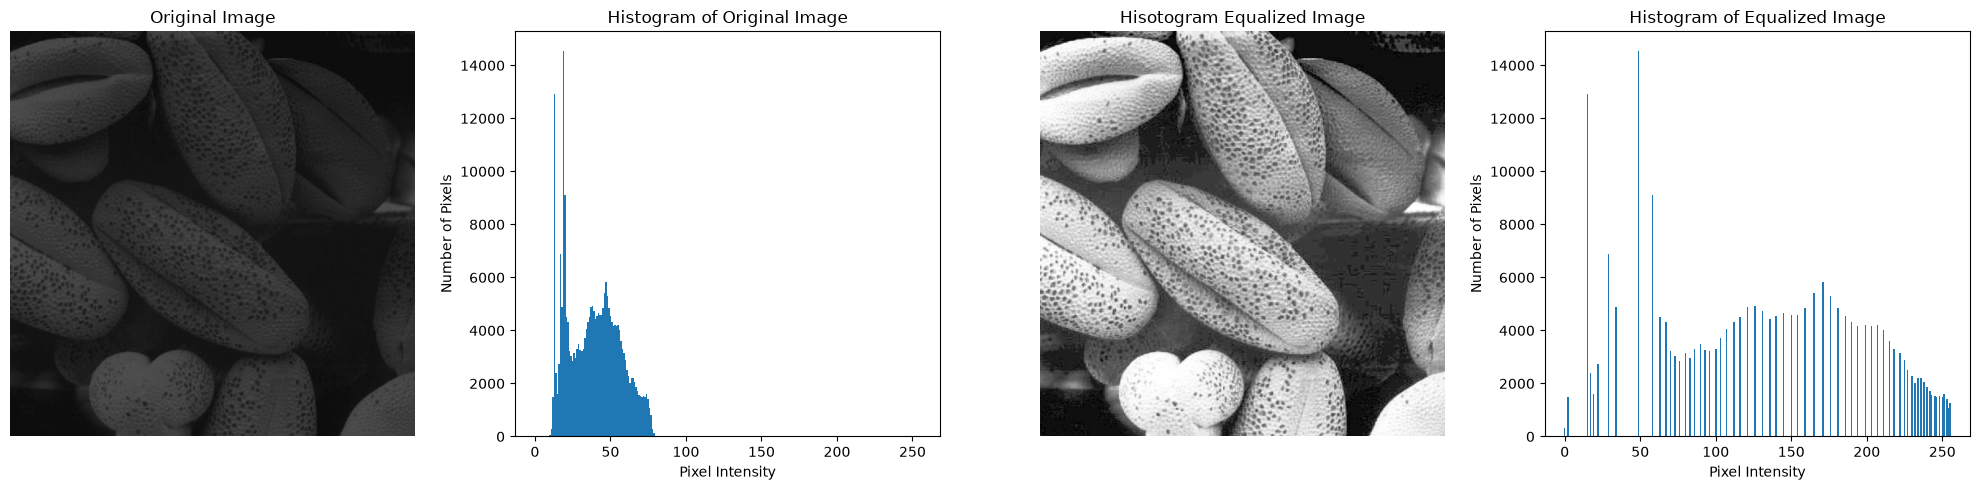

In [156]:
def histogram_equalization(im):

    img = cv.imread(im, cv.IMREAD_GRAYSCALE)
    height,width = img.shape[:2]
    hist1 = cv.calcHist([img], [0], None, [256], [0,256])

    fig, ax = plt.subplots(1, 4, figsize=(20, 5))
    ax[0].imshow(img, cmap='gray', vmin=0, vmax=255)
    ax[0].set_title("Original Image")
    ax[0].axis('off')

    ax[1].bar(np.arange(256), hist1.flatten(), width=1)
    ax[1].set_xlabel("Pixel Intensity")
    ax[1].set_ylabel("Number of Pixels")
    ax[1].set_title("Histogram of Original Image")

    cdf = 0
    mapping = np.arange(256)
    for k in range(256):
        cdf += hist1[k]
        mapping[k] = round(255*cdf/(height*width))

    equalized_img = mapping[img].astype(np.uint8)
    ax[2].imshow(equalized_img, cmap='gray')
    ax[2].set_title("Hisotogram Equalized Image")
    ax[2].axis('off')

    hist2 = cv.calcHist([equalized_img], [0], None, [256], [0,256])
    ax[3].bar(np.arange(256), hist2.flatten(), width=1)
    ax[3].set_xlabel("Pixel Intensity")
    ax[3].set_ylabel("Number of Pixels")
    ax[3].set_title("Histogram of Equalized Image")

    plt.tight_layout()
    plt.show(block=False)
    
    
histogram_equalization("shells.jpg")

The original histogram is narrow and concentrated in a small intensity range **(10 - 80)**. This means the image has low contrast. Histogram equalization uses the cumulative distribution function (CDF) to remap intensities so they spread across the full **0–255** range. After equalization, the histogram is more spread out and flatter. The resulting image shows more visible detail in both dark and bright regions. This confirms histogram equalization improves contrast, especially for images with a narrow intensity distribution.

<h2 align="left">Question 6</h2>

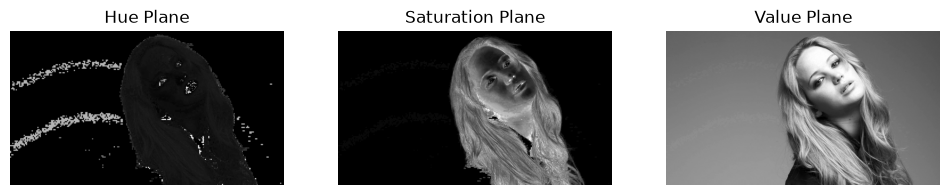

In [157]:
img_bgr = cv.imread('jennifer_lawrence.jpg')
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)

h, s, v = cv.split(img_hsv)

plt.figure(figsize=(12, 8))

plt.subplot(1, 3, 1)
plt.imshow(h, cmap='gray'); 
plt.title('Hue Plane');
plt.axis('off');

plt.subplot(1, 3, 2)
plt.imshow(s, cmap='gray'); 
plt.title('Saturation Plane');
plt.axis('off');

plt.subplot(1, 3, 3)
plt.imshow(v, cmap='gray'); 
plt.title('Value Plane');
plt.axis('off');

**Plane Selection For Masking and Foreground Extraction:** 

After analyzing all three H,S,V planes, **saturation plane** can be used to extract the foreground mask since it shows a very clear distinction between background and foreground unlike other planes. Then using "bitwise-and" operator between the **value plane** and the **foreground mask**, foreground can be extracted while using "bitwise-and" operator between the **value plane** and the **inverse foreground mask**, background can be extracted. 

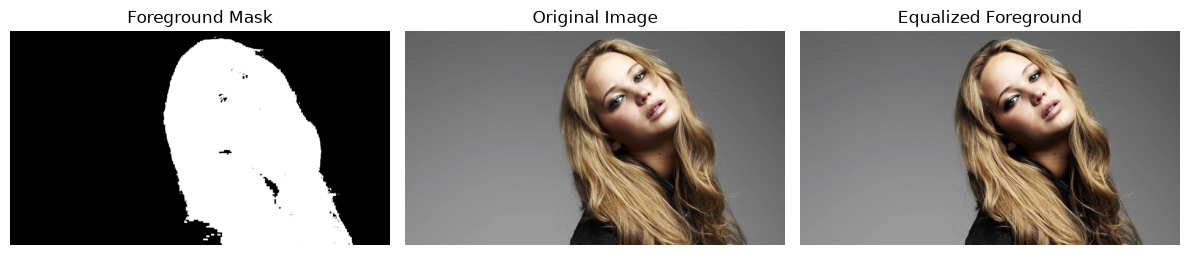

In [158]:
_, mask = cv.threshold(s, 13, 255, cv.THRESH_BINARY)
v_foreground = cv.bitwise_and(v, v, mask=mask) #Foreground only

hist, bins = np.histogram(v_foreground[mask == 255], bins=256, range=[0, 256])
cdf = hist.cumsum()
mapping = np.arange(256)
for k in range(len(cdf)):
    mapping[k] = round(255*cdf[k]/cdf.max())
v_equalized_foreground = mapping[v_foreground].astype(np.uint8)

mask_inv = cv.bitwise_not(mask)
v_background = cv.bitwise_and(v, v, mask=mask_inv) #Background only

v_final = cv.add(v_equalized_foreground, v_background)
img_hsv_final = cv.merge((h, s, v_final))
img_final_rgb = cv.cvtColor(img_hsv_final, cv.COLOR_HSV2RGB)

plt.figure(figsize=(12, 8))
plt.subplot(1, 3, 1)
plt.imshow(mask, cmap='gray'); 
plt.title('Foreground Mask'); 
plt.axis('off');

plt.subplot(1, 3, 2)
plt.imshow(img_rgb);
plt.title('Original Image'); 
plt.axis('off');

plt.subplot(1, 3, 3)
plt.imshow(img_final_rgb); 
plt.title('Equalized Foreground');
plt.axis('off');

plt.tight_layout()
plt.show(block=False)

The foreground (hair and face) has higher saturation than the plain gray background. As mentioned earlier, it is used for thresholding and then the mask correctly isolates the person's shape, with small noise near the hair edges. Histogram equalization is applied only to the value plane of the foreground. This improves contrast in the person's region without changing the background. The final image shows better detail in the hair and face while the background stays the same as original.

<h2 align="left">Question 7</h2>

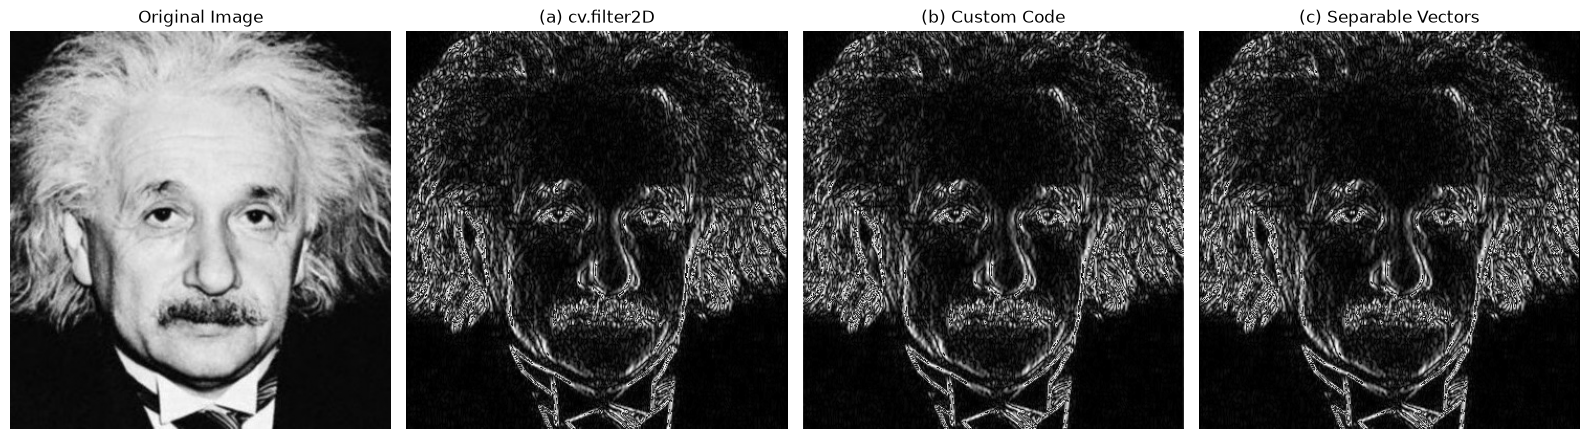

In [159]:
img = cv.imread('albert_einstein.jpg', cv.IMREAD_GRAYSCALE)

sobel_x = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float32)

# (a) Using existing cv.filter2D
filtered_a_float = cv.filter2D(img, cv.CV_64F, sobel_x)
filtered_a = np.uint8(np.absolute(filtered_a_float))

# (b) Custom code for Sobel filtering
def sobel_filter2D(image):

    h, w = image.shape
    sobel_x = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float32)
    k_h, k_w = sobel_x.shape
    
    padded_img = np.pad(image, ((1,1), (1,1)), mode='constant') 

    output = np.zeros((h, w), dtype=np.float64)
    for i in range(h):
        for j in range(w):
            region = padded_img[i:i+k_h, j:j+k_w]
            output[i, j] = np.sum(region * sobel_x)
            
    return output

filtered_b_float = sobel_filter2D(img)
filtered_b = np.uint8(np.absolute(filtered_b_float))


# (c) Using separable property
sobel_x_col = np.array([[1], [2], [1]], dtype=np.float32)
sobel_x_row = np.array([[1, 0, -1]], dtype=np.float32)

filtered_c_step1 = cv.filter2D(img, cv.CV_64F, sobel_x_row)
filtered_c_step2 = cv.filter2D(filtered_c_step1, cv.CV_64F, sobel_x_col)
filtered_c = np.uint8(np.absolute(filtered_c_step2))

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(filtered_a, cmap='gray')
plt.title('(a) cv.filter2D')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(filtered_b, cmap='gray')
plt.title('(b) Custom Code')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(filtered_c, cmap='gray')
plt.title('(c) Separable Vectors')
plt.axis('off')

plt.tight_layout()
plt.show()

All three methods (filter2D, custom code, and separable filtering) give the same result. This is expected since the Sobel kernel can be decomposed into a smoothing vector [1,2,1] and a derivative vector [1,0,-1]. The separable method is more efficient because it needs **fewer multiplications per pixel** than direct 2D convolution.

- Special Note: Before plotting graphs, I used *np.uint8(np.absolute(filtered_c_step2))* to map the pixel values between 0-255 unlike we did in lectures which ended up with grayish images.

<h2 align="left">Question 8</h2>

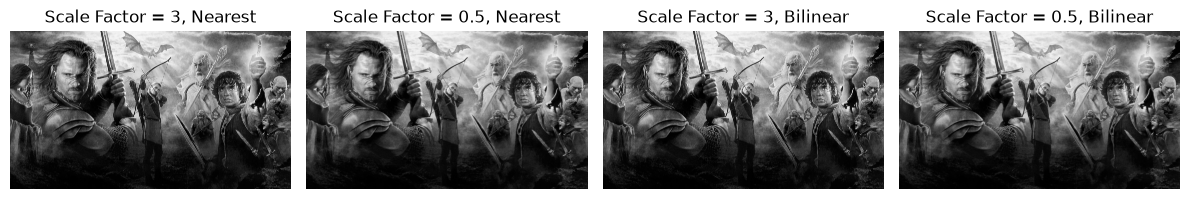

In [160]:
#Method = 1: Nearest Neighbor Interpolation
#Method = 2: Bilinear Interpolation
def img_scale(im, scale_factor, method=1):

    img = cv.imread(im, cv.IMREAD_GRAYSCALE)
    assert img is not None
    h, w = img.shape
    new_h, new_w = int(h * scale_factor), int(w * scale_factor)
    output = np.zeros((new_h, new_w), dtype=np.float64)

    if method == 1:
        #Nearest neighbor interpolation
        for i in range(new_h):
            for j in range(new_w):
                x = int(i/scale_factor)
                y = int(j/scale_factor)

                output[i, j] = img[x, y]
    
    else:
        #Bilinear interpolation
        for i in range(new_h):
            for j in range(new_w):
                x = i / scale_factor
                y = j / scale_factor

                x1 = int(x)
                x2 = min(x1 + 1, h-1)
                y1 = int(y)
                y2 = min(y1 + 1, w-1)

                dx = x - x1
                dy = y - y1

                Q11 = img[x1, y1]
                Q12 = img[x1, y2]
                Q21 = img[x2, y1]
                Q22 = img[x2, y2]

                output[i, j] = (Q11 * (1 - dx) * (1 - dy) +
                                Q21 * (dx) * (1 - dy) +
                                Q12 * (1 - dx) * (dy) +
                                Q22 * (dx) * (dy))
    
    return output.astype(np.uint8)

img1 = img_scale("im01.png", 3, method=1)
img2 = img_scale("im01.png", 0.5, method=1)
img3 = img_scale("im01.png", 3, method=2)
img4 = img_scale("im01.png", 0.5, method=2)

plt.figure(figsize=(12, 5))

plt.subplot(1, 4, 1)
plt.imshow(img1, cmap='gray')
plt.title('Scale Factor = 3, Nearest')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img2, cmap='gray')
plt.title('Scale Factor = 0.5, Nearest')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img3, cmap='gray')
plt.title('Scale Factor = 3, Bilinear')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img4, cmap='gray')
plt.title('Scale Factor = 0.5, Bilinear')
plt.axis('off')

plt.tight_layout()
plt.show()

**SSD Error in Interpolations:**

Image 1 - Nearest Neighbor SSD: 137.2096
Image 1 - Bilinear SSD: 201.4494
Image 2 - Nearest Neighbor SSD: 26.6863
Image 2 - Bilinear SSD: 49.5564


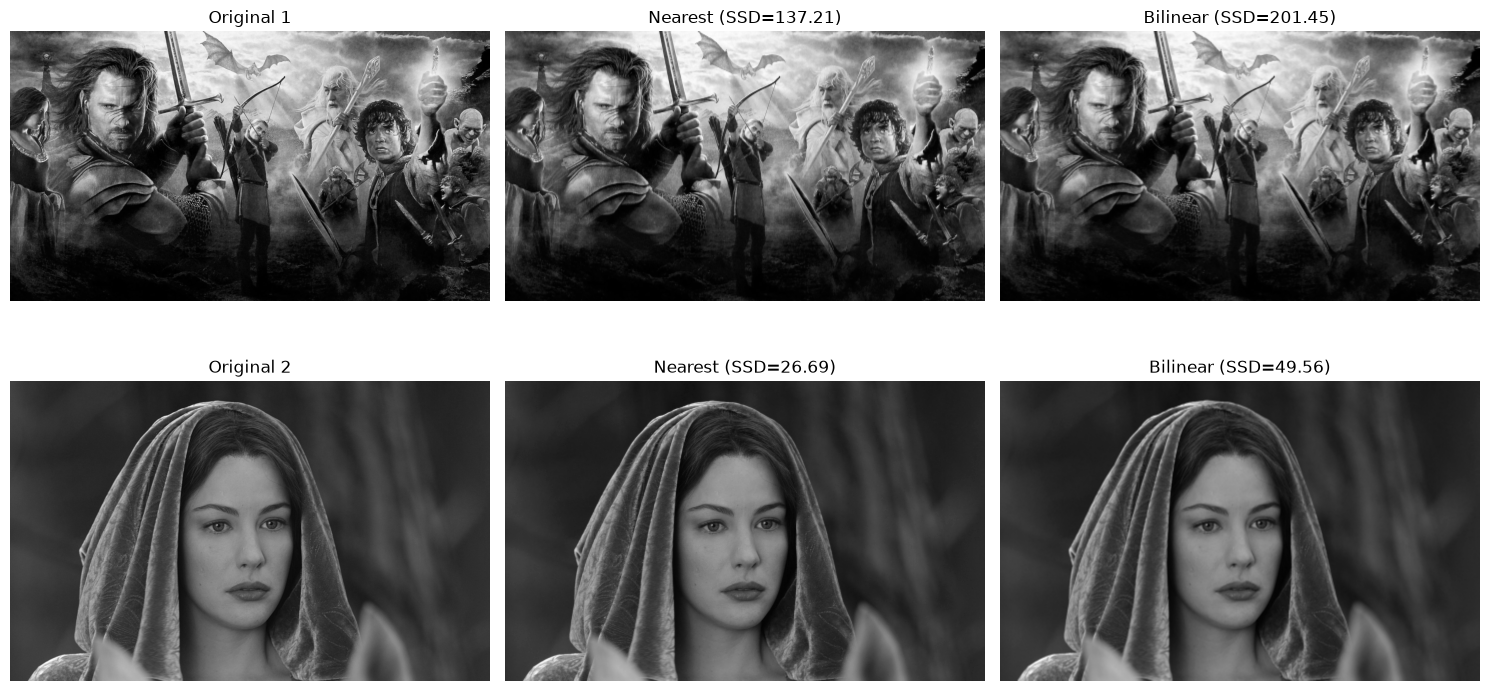

In [161]:
def normalized_ssd(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    ssd = np.sum((img1 - img2) ** 2)
    normalized = ssd / (img1.shape[0] * img1.shape[1])
    return normalized

small_img1_path = "im01small.png"
large_img1_path = "im01.png"
small_img2_path = "im02small.png"
large_img2_path = "im02.png"

large1 = cv.imread(large_img1_path, cv.IMREAD_GRAYSCALE)
large2 = cv.imread(large_img2_path, cv.IMREAD_GRAYSCALE)
small1 = cv.imread(small_img1_path, cv.IMREAD_GRAYSCALE)
small2 = cv.imread(small_img2_path, cv.IMREAD_GRAYSCALE)

scale_factor = int(large1.shape[0] / small1.shape[0])  

upscaled1_nn = img_scale(small_img1_path, scale_factor, 1)
upscaled1_bi = img_scale(small_img1_path, scale_factor, 2)
upscaled2_nn = img_scale(small_img2_path, scale_factor, 1)
upscaled2_bi = img_scale(small_img2_path, scale_factor, 2)

# Resize upscaled outputs to exactly match original dimensions
# in case of rounding mismatch
upscaled1_nn = cv.resize(upscaled1_nn, 
                         (large1.shape[1], large1.shape[0]))
upscaled1_bi = cv.resize(upscaled1_bi, 
                         (large1.shape[1], large1.shape[0]))
upscaled2_nn = cv.resize(upscaled2_nn, 
                         (large2.shape[1], large2.shape[0]))
upscaled2_bi = cv.resize(upscaled2_bi, 
                         (large2.shape[1], large2.shape[0]))

ssd1_nn = normalized_ssd(large1, upscaled1_nn)
ssd1_bi = normalized_ssd(large1, upscaled1_bi)
ssd2_nn = normalized_ssd(large2, upscaled2_nn)
ssd2_bi = normalized_ssd(large2, upscaled2_bi)

print(f"Image 1 - Nearest Neighbor SSD: {ssd1_nn:.4f}")
print(f"Image 1 - Bilinear SSD: {ssd1_bi:.4f}")
print(f"Image 2 - Nearest Neighbor SSD: {ssd2_nn:.4f}")
print(f"Image 2 - Bilinear SSD: {ssd2_bi:.4f}")

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

ax[0,0].imshow(large1, cmap='gray'); 
ax[0,0].set_title('Original 1'); ax[0,0].axis('off')
ax[0,1].imshow(upscaled1_nn, cmap='gray'); 
ax[0,1].set_title(f'Nearest (SSD={ssd1_nn:.2f})'); ax[0,1].axis('off')
ax[0,2].imshow(upscaled1_bi, cmap='gray');
ax[0,2].set_title(f'Bilinear (SSD={ssd1_bi:.2f})'); ax[0,2].axis('off')

ax[1,0].imshow(large2, cmap='gray'); 
ax[1,0].set_title('Original 2'); ax[1,0].axis('off')
ax[1,1].imshow(upscaled2_nn, cmap='gray');
ax[1,1].set_title(f'Nearest (SSD={ssd2_nn:.2f})'); ax[1,1].axis('off')
ax[1,2].imshow(upscaled2_bi, cmap='gray'); 
ax[1,2].set_title(f'Bilinear (SSD={ssd2_bi:.2f})'); ax[1,2].axis('off')

plt.tight_layout()
plt.show()

**Important Note:**

Bilinear interpolation gave a higher SSD than nearest neighbor for both images, which is unexpected. This is likely because bilinear averaging blurs fine details and edges, increasing pixel-wise error against a sharp original. Nearest neighbor copies exact pixel values without averaging, so it can align closer to true intensities despite looking blockier. The extra **cv.resize** step also adds a second smoothing pass, affecting bilinear more since it is already smoothed once. This shows SSD does not always match visual quality because bilinear looks normally better to the eye but does not always minimize pixel error.

<h2 align="left">Question 9</h2>

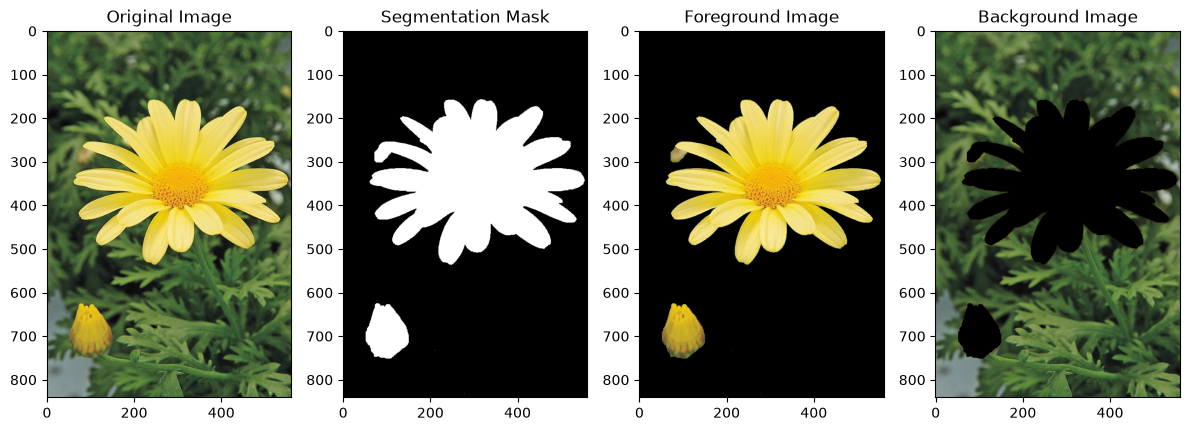

In [162]:
img_bgr = cv.imread("yellow_flower.jpg")
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)    

mask = np.zeros(img_rgb.shape[:2], np.uint8)

bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

height, width = img_rgb.shape[:2]
#Manually defined rectangle around the object of interest 
#such that the whole flower is included in the box.
rect = (5, 5, width - 10, height - 10) 

cv.grabCut(img_rgb, mask, rect, bgdModel, fgdModel, 5, cv.GC_INIT_WITH_RECT)
mapping = np.array([0, 1, 0, 1], dtype=np.uint8)
mask = mapping[mask]
inv_mask = 1 - mask

foreground = cv.bitwise_and(img_rgb, img_rgb, mask=mask)
background = cv.bitwise_and(img_rgb, img_rgb, mask=inv_mask)

plt.figure(figsize=(12, 5))
plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title('Original Image')

plt.subplot(1, 4, 2)
plt.imshow(mask, cmap='gray')
plt.title('Segmentation Mask')  

plt.subplot(1, 4, 3)
plt.imshow(foreground)
plt.title('Foreground Image')

plt.subplot(1, 4, 4)
plt.imshow(background)
plt.title('Background Image')
plt.tight_layout()
plt.show(block=False)

GrabCut successfully separates the flower from the background using the segmentation mask. The mask closely follows the petal boundaries but has small errors near thin or curved edges. I tried using different number of iterations (by changing a default parameter in the grabcut function) to separate the flower smoothly from the background but **5** was found out be the ideal number of iterations to get a moderate smooth separation and more than 5 iterations did not make a better result.

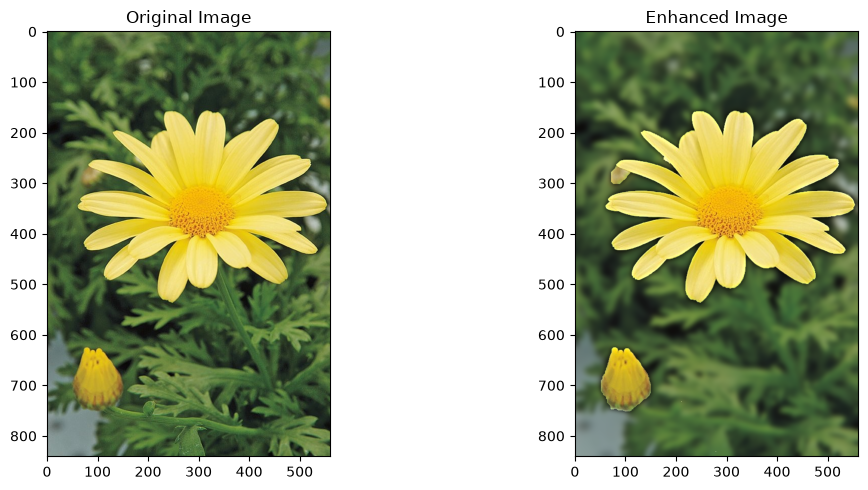

In [163]:
blurred_background = cv.GaussianBlur(background, (31, 31), 0)
enhanced_img = cv.add(foreground, blurred_background)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(enhanced_img)
plt.title('Enhanced Image')

plt.tight_layout()
plt.show(block=False)

**Answer for Part C:**
The background just beyond the edge of the flower is dark because of a side effect from the blurring process. Removing the foreground flower leaves a black hole (zero intensity pixels) in the background image. Then we apply a Gaussian blur to this background. The blur effect mixes the black pixels from the hole with the nearby background pixels. This mixing makes the background pixels right next to the hole much darker. Finally, we paste the sharp flower back on top.The flower covers the hole, but the darkened background pixels are still visible just outside the edges.

<h2 align="left">Question 10</h2>

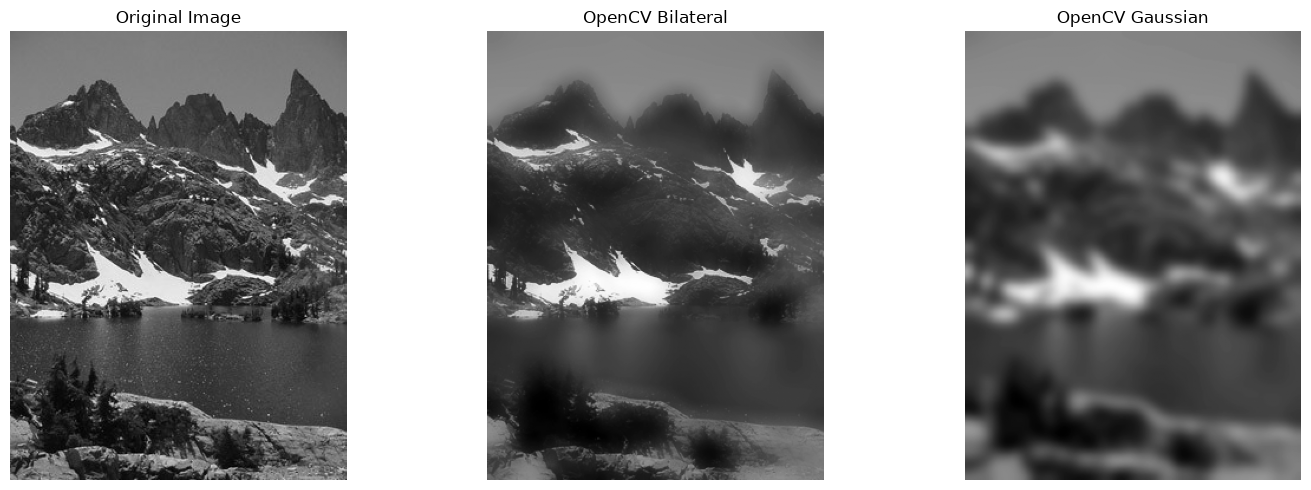

In [164]:
img = cv.imread('mountains.jpg', cv.IMREAD_GRAYSCALE)

diameter = 31
sigma_color = 75.0
sigma_space = 75.0

# (a) OpenCV's Built-in Bilateral Filter
opencv_filtered = cv.bilateralFilter(img, diameter, sigma_color, sigma_space)
Gaussian_filtered = cv.GaussianBlur(img, (diameter, diameter), 0)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(opencv_filtered, cmap='gray')
plt.title('OpenCV Bilateral')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(Gaussian_filtered, cmap='gray')
plt.title('OpenCV Gaussian')
plt.axis('off')

plt.tight_layout()
plt.show()


Mean Squared Error between Custom and OpenCV Bilateral: 3.6454


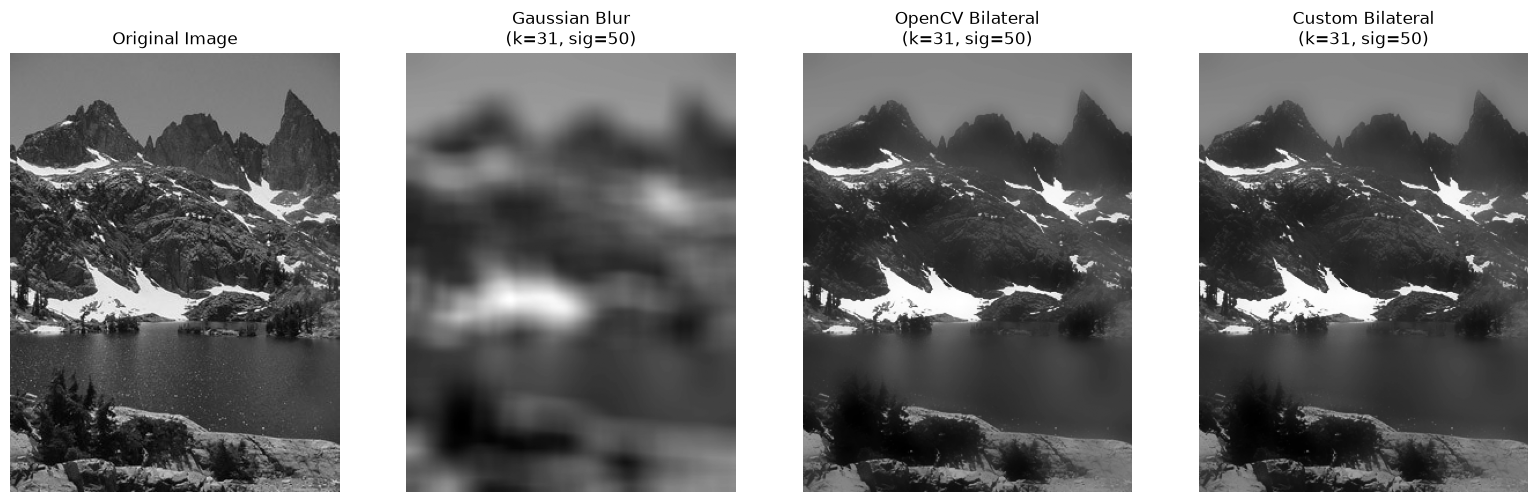

In [165]:
def bilaterl_filter(im_path, diameter, sigma_color, sigma_space):
    img = cv.imread(im_path, cv.IMREAD_GRAYSCALE)
    assert img is not None
    h, w = img.shape

    radius = diameter // 2 
    
    img_float = img.astype(np.float64)
    padded_img = np.pad(img_float, radius, mode='reflect')
    output = np.zeros((h, w), dtype=np.float64)

    x, y = np.meshgrid(np.arange(-radius, radius + 1), 
                       np.arange(-radius, radius + 1))
    spatial_weights = np.exp(-(x**2 + y**2) / (2 * sigma_space**2))
    
    for i in range(h):
        for j in range(w):
            i_padded = i + radius
            j_padded = j + radius
            
            local_region = padded_img[i_padded - radius:i_padded + radius + 1, 
                                      j_padded - radius:j_padded + radius + 1]

            # Range Gaussian weights
            intensity_diff = local_region - img_float[i, j]
            range_weights = np.exp(-(intensity_diff**2) / (2 * sigma_color**2))

            combined_weights = spatial_weights * range_weights
            combined_weights /= np.sum(combined_weights)

            output[i, j] = np.sum(combined_weights * local_region)

    return output.astype(np.uint8)


image_file = 'mountains.jpg' 
diameter = 31
sigma_color = 50
sigma_space = 50

original_img = cv.imread(image_file, cv.IMREAD_GRAYSCALE)
custom_filtered = bilaterl_filter(image_file, diameter,
                                   sigma_color, sigma_space)
cv_bilateral = cv.bilateralFilter(original_img, diameter,
                                   sigma_color, sigma_space)
gaussian_blurred = cv.GaussianBlur(original_img,
                                  (diameter, diameter), sigma_space)

# Quantitative Measure: Mean Squared Error (MSE)
diff = custom_filtered.astype(np.float64) - cv_bilateral.astype(np.float64)
mse = np.mean(diff ** 2)
print(f"Mean Squared Error between Custom and OpenCV Bilateral: {mse:.4f}")

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(original_img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(gaussian_blurred, cmap='gray')
plt.title(f'Gaussian Blur\n(k={diameter}, sig={sigma_space})')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(cv_bilateral, cmap='gray')
plt.title(f'OpenCV Bilateral\n(k={diameter}, sig={sigma_space})')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(custom_filtered, cmap='gray')
plt.title(f'Custom Bilateral\n(k={diameter}, sig={sigma_space})')
plt.axis('off')

plt.tight_layout()
plt.show()

Gaussian blur smooths the image evenly, including across edges. This causes edges like mountain ridges and rock outlines to become blurry. Bilateral filtering smooths flat regions but **preserves strong edges**. This is because it weights pixels by both *spatial distance and intensity difference*. Pixels across an edge have large intensity difference, so they get less weight. The custom bilateral filter gives results close to OpenCV's built-in function. The MSE between them is low (3.6454)